## Imports and set data path

In [37]:
# Imports
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import gaussian_kde
import math
import rounders
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)
alt.data_transformers.disable_max_rows()


# Set data path here
data_path = 'data/airfoil_9k_data.h5'


In [2]:
# %pip install altair
# %pip install rounders

## Explore contents and architecture of .h5 data file

`Data Structure` <br>
The .h5 data file is structured as follows: <br>

|-- root (group, 3 members) <br>
 &emsp;&emsp;	|-- shape (group, 4 members) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- landmarks (dataset, shape(8996, 1001, 2)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- grassmann (dataset, shape(8996, 4)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- cst (dataset, shape(8996, 19)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- bezier (dataset, shape(8996, 15)) <br>
 &emsp;&emsp;	|-- alpha+04 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>
 &emsp;&emsp;	|-- alpha+12 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>


** The flow fields for the 8,996 airfoils are indexed by zero-padded group names 'XXXX' from 0000 to 8995. The number of mesh points for each airfoil flow field is different and is determined by the airfoil's shape.

In [39]:
# Open file and print the top level group names/keys
# This data set contains 8996 unique airfoil shapes
# The alpha+XX groups represents the airfoil angle of attack (4 and 12 degrees) and contain datasets for the coeffients of drag, lift, and moment
# The shape group contains 4 datasets representing the different parameterizations of the airfoil geometries.
with h5py.File(data_path, 'r') as hf:
    top_groups = [k for k in hf.keys()]
    print(top_groups)


['alpha+04', 'alpha+12', 'shape']


In [40]:
# Explore contents of the three top level groups

# Each alpha+XX group contains 3 datasets and 1 group:
#   C_d: dataset, (8996,) array representing the coeffients of drag for each airfoil geometry at the specified angle of attack
#   C_l: dataset, (8996,) array representing the coeffients of lift for each airfoil geometry at the specified angle of attack
#   C_m: dataset, (8996,) array representing the coeffients of moment for each airfoil geometry at the specified angle of attack
#   flow_field: group containing 8996 subgroups associated with each airfoil and containing 7 datasets:
#      x: (n_mesh,) array representing the x locations of the mesh points
#      y: (n_mesh,) array representing the y locations of the mesh points
#      rho: (n_mesh,) array representing the flow density at each mesh point
#      rho_u: (n_mesh,) array representing the flow momentum in the x-direction at each mesh point
#      rho_v: (n_mesh,) array representing the flow momentum in the y-direction at each mesh point
#      e: (n_mesh,) array representing the total energy in the flow at each mesh point
#      omega: (n_mesh,) array representing the flow vorticity at each mesh point
#   Note that the number of mesh point n_mesh can be different for each airfoil
# The shape group contains 4 members representing different paramerizations of the airfoil geometry:
#   landmarks:  dataset (8996, 1001, 2) array representing the geometries of each airfoil via (x, y) landmarks.
#   grassmann:  dataset (8996, 4) array representing the geometries of each airfoil via Grassmann representations.
#   cst:        dataset (8996, 19) array representing the geometries of each airfoil via Class-Shape transformations.
#   bezier:     dataset (8996, 15) array representing the goemetries of each airfoil via Bezier curves.

with h5py.File(data_path, 'r') as hf:
    for name in top_groups:
        print('-------------------------------------------------')
        print('Group Name:', name)
        print('Group Info:', hf[name])
        print('')
        
        if 'alpha' in name:
            print('Aerodynamic quantities:')
            for key in hf[name].keys():
                if 'flow' in key:
                    for i in range(3):
                        print('Flow Field data for airfoil {:04d}'.format(i))
                        for flow_key in hf[name][key]['{:04d}'.format(i)].keys():
                            print('  ', hf[name][key]['{:04d}'.format(i)][flow_key])    
                else:
                    print(hf[name][key])
        else:
            print('Airfoil shape data:')
            for key in hf[name].keys():
                print(hf[name][key])
    print('-------------------------------------------------')
    

-------------------------------------------------
Group Name: alpha+04
Group Info: <HDF5 group "/alpha+04" (4 members)>

Aerodynamic quantities:
<HDF5 dataset "C_d": shape (8996,), type "<f8">
<HDF5 dataset "C_l": shape (8996,), type "<f8">
<HDF5 dataset "C_m": shape (8996,), type "<f8">
Flow Field data for airfoil 0000
   <HDF5 dataset "e": shape (55082,), type "<f8">
   <HDF5 dataset "omega": shape (55082,), type "<f8">
   <HDF5 dataset "rho": shape (55082,), type "<f8">
   <HDF5 dataset "rho_u": shape (55082,), type "<f8">
   <HDF5 dataset "rho_v": shape (55082,), type "<f8">
   <HDF5 dataset "x": shape (55082,), type "<f8">
   <HDF5 dataset "y": shape (55082,), type "<f8">
Flow Field data for airfoil 0001
   <HDF5 dataset "e": shape (56422,), type "<f8">
   <HDF5 dataset "omega": shape (56422,), type "<f8">
   <HDF5 dataset "rho": shape (56422,), type "<f8">
   <HDF5 dataset "rho_u": shape (56422,), type "<f8">
   <HDF5 dataset "rho_v": shape (56422,), type "<f8">
   <HDF5 dataset 

## Downsizing the Data Source

Attempted but it errored.

In [41]:
# n = 1000  # number of samples to keep

# with h5py.File('airfoil_9k_data.h5', 'r') as src, \
#      h5py.File('airfoil_1k_data.h5', 'w') as dst:
#     for group in src.keys():
#         for dataset in src[group].keys():
#             data = src[group][dataset][:n]
#             dst.require_group(group).create_dataset(dataset, data=data)

# print('Done')

## Explore Airfoil Shapes & Parameterizations

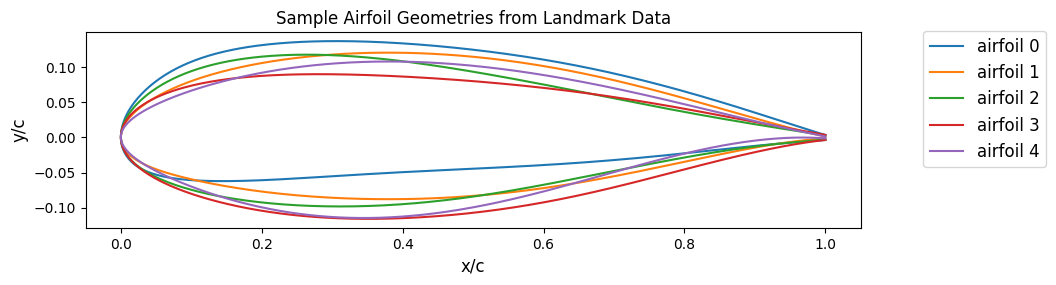

In [42]:
# plt.close('all')
# # clears current figure
# # Visualize the first 5 airfoil geometries using the landmarks dataset
# plt.figure(figsize=(10, 6))
# with h5py.File(data_path, 'r') as hf:
#     landmarks = hf['shape']['landmarks'][()]
#     af_shape_count = 0
#     for landmark in landmarks[0:20]:
#         plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
#         af_shape_count += 1
# plt.xlabel('x/c', fontsize=12)
# plt.ylabel('y/c', fontsize=12)
# plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
# plt.title('Sample Airfoil Geometries from Landmark Data')
# plt.show()

import dask.array as da

plt.close('all')
plt.figure(figsize=(10, 6))

with h5py.File(data_path, 'r') as hf:
    landmarks = da.from_array(hf['shape']['landmarks'], chunks=500)
    landmarks_subset = landmarks[0:5].compute()  # only loads 20 rows

for i, landmark in enumerate(landmarks_subset):
    plt.plot(landmark[:, 0], landmark[:, 1], label=f'airfoil {i}')

plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()


In [36]:
# # Capture reduced dimensionality parameterizations as objects and print shapes
# with h5py.File(data_path, 'r') as hf:
#     grassmann = hf['shape']['grassmann'][()]
#     print('Grassmann')
#     print(grassmann.shape)
    
#     cst = hf['shape']['cst'][()]
#     print('CST')
#     print(cst.shape)
    
#     bezier = hf['shape']['bezier'][()]
#     print('Bezier')
#     print(bezier.shape)

with h5py.File(data_path, 'r') as hf:
    grassmann = da.from_array(hf['shape']['grassmann'], chunks=500)
    print('Grassmann', grassmann.shape)

    cst = da.from_array(hf['shape']['cst'], chunks=500)
    print('CST', cst.shape)

    bezier = da.from_array(hf['shape']['bezier'], chunks=500)
    print('Bezier', bezier.shape)


Grassmann (8996, 4)
CST (8996, 19)
Bezier (8996, 15)


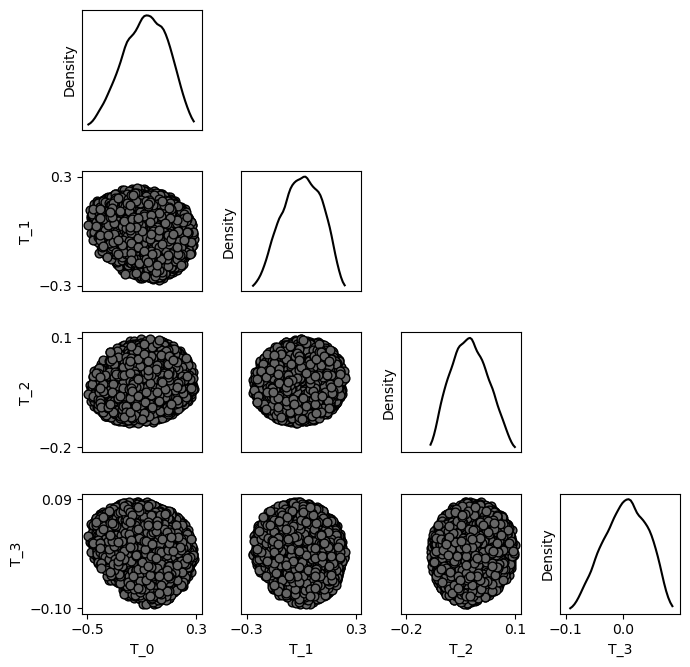

In [6]:
## Visualize distributions of Grassmann parameters
# Capture number of parameters in grassmann representation
m = grassmann.shape[1]
# Create list to hold upper and lower limits for visualizations
grassmann_limits = []
for i in range(m):
    # Capture min and max values in each grassmann parameter across all airfoils
    lower = grassmann[:,i].min()
    upper = grassmann[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    grassmann_limits.append([lower,upper])

# Create labels for grassmann parameters
grassmann_labels = ['T_{}'.format(i) for i in range(m)]

# Plot marginal distributions of the grassmann data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(grassmann[:,i].min(), grassmann[:,i].max())
            kde = gaussian_kde(grassmann[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]),
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(grassmann[:,j], grassmann[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(grassmann_limits[j])
            plt.yticks(grassmann_limits[i])
            
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(grassmann_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(grassmann_limits[j][0]-0.05*np.ptp(grassmann_limits[j]), 
                     grassmann_limits[j][-1]+0.05*np.ptp(grassmann_limits[j]))
            plt.ylim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]), 
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


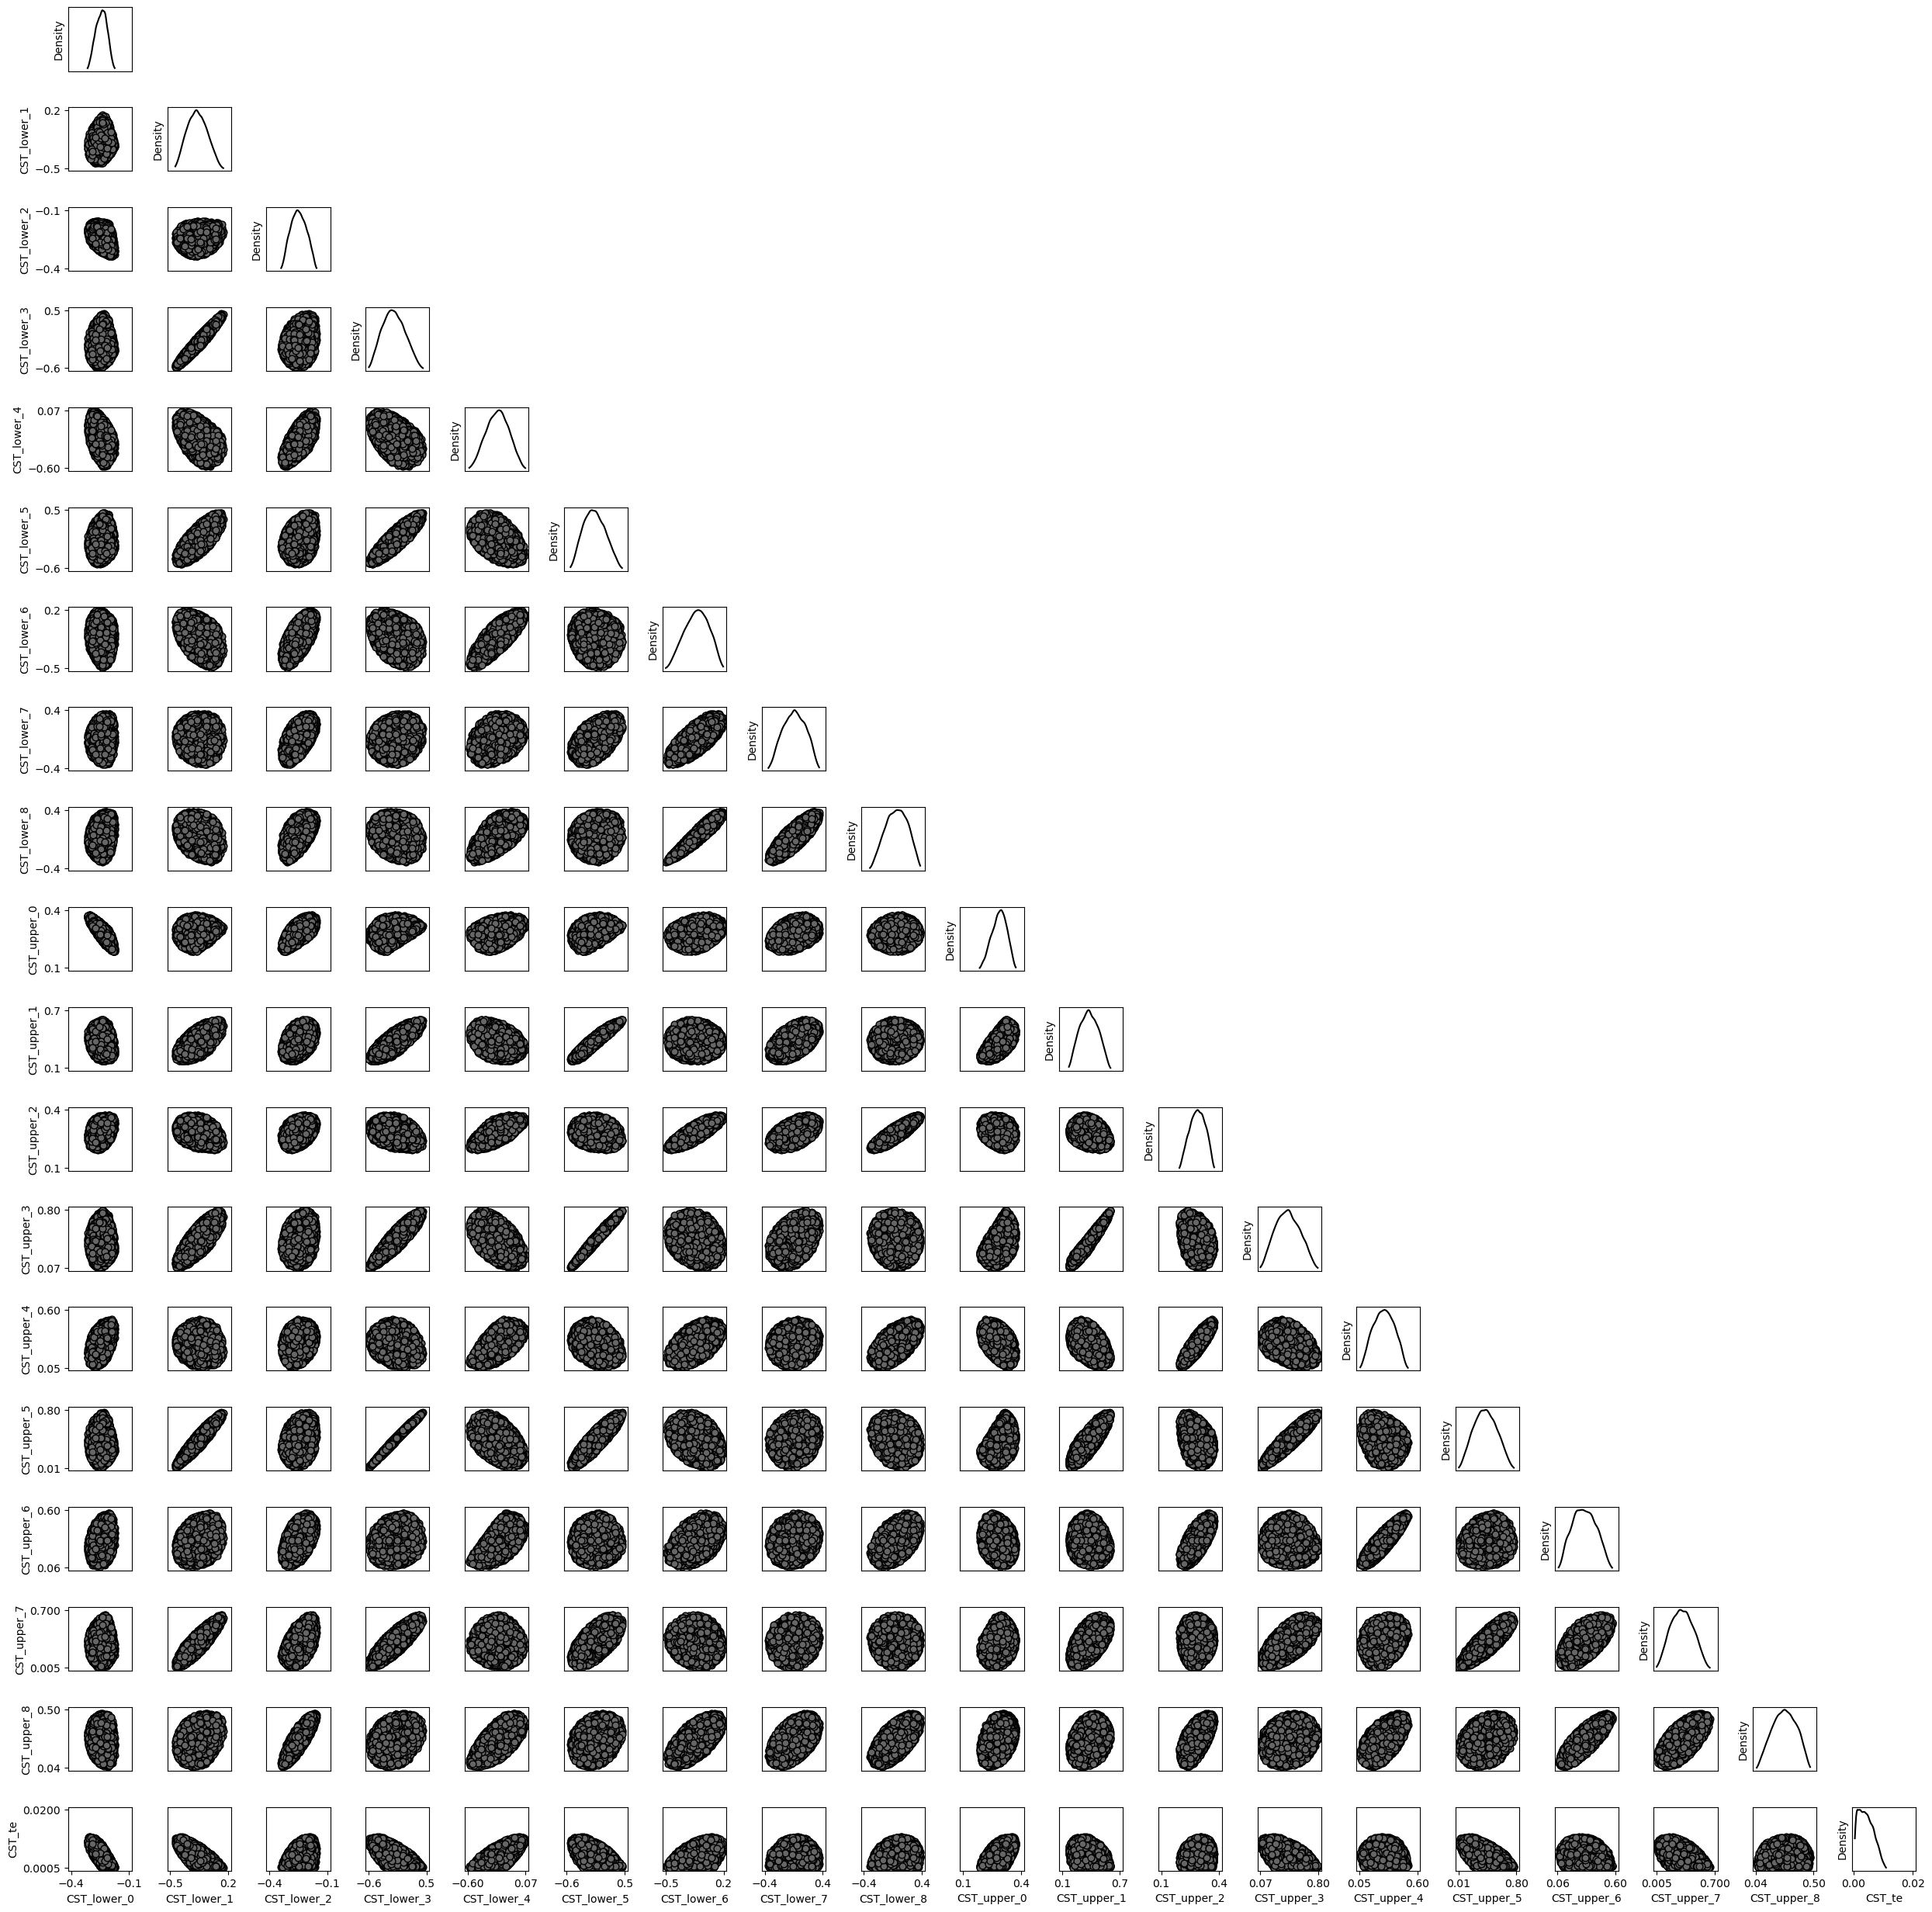

In [7]:
## Visualize distributions of CST parameters
# Capture number of parameters in CST representation
m = cst.shape[1]
# Create list to hold upper and lower limits for visualizations
cst_limits = []
for i in range(m):
    # Capture min and max values in each CST parameter across all airfoils
    lower = cst[:,i].min()
    upper = cst[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    cst_limits.append([lower,upper])

# Create labels for CST parameters
cst_labels = ['CST_lower_{}'.format(i) for i in range(int((m-1)/2))]
cst_labels.extend(['CST_upper_{}'.format(i) for i in range(int((m-1)/2))])
cst_labels.extend(['CST_te'])

# Plot marginal distributions of the CST data
plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst[:,i].min(), cst[:,i].max())
            kde = gaussian_kde(cst[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(cst[:,j], cst[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]), 
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]), 
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


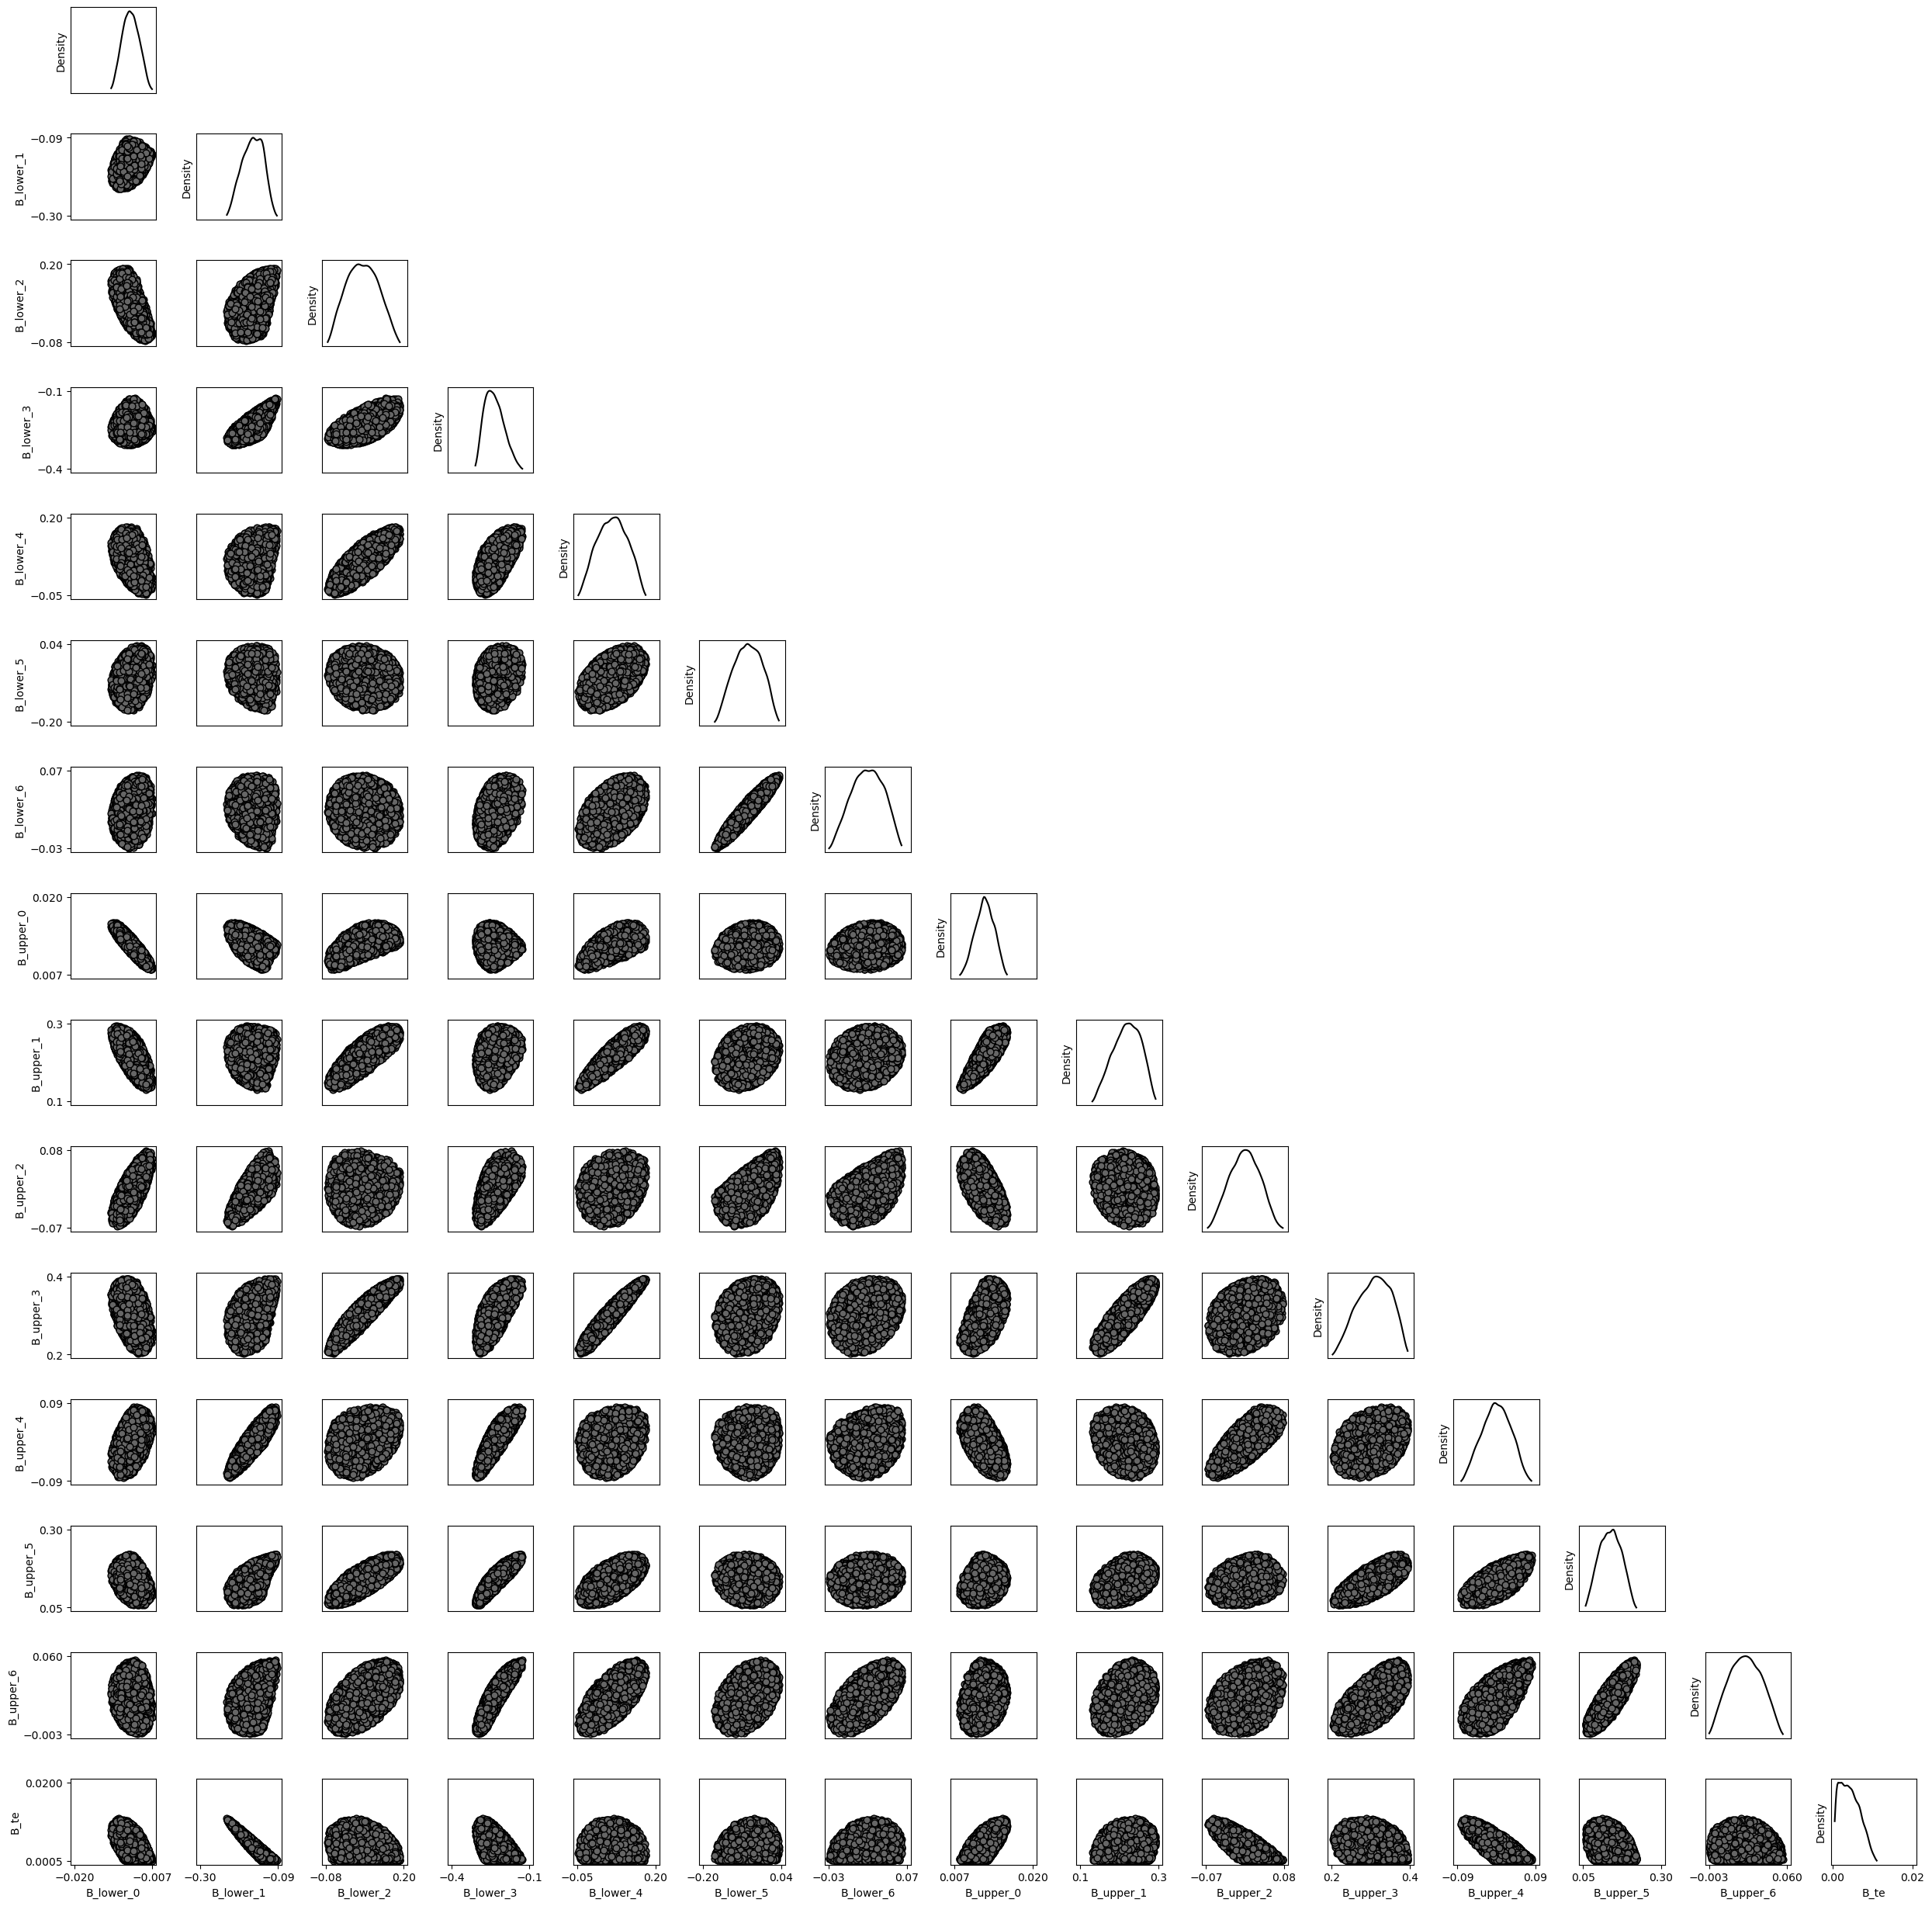

In [8]:
## Visualize distributions of Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier[:,i].min()
    upper = bezier[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_lower_{}'.format(i) for i in range(int((m-1)/2))]
bezier_labels.extend(['B_upper_{}'.format(i) for i in range(int((m-1)/2))])
bezier_labels.extend(['B_te'])

# Plot marginal distributions of the bezier data
plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier[:,i].min(), bezier[:,i].max())
            kde = gaussian_kde(bezier[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier[:,j], bezier[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Airfoil Shape and Aerodynamic Properties

In [9]:
# Parse the landmark datasets and extract thickness along the chord and camber line
with h5py.File(data_path, 'r') as hf:    
    landmarks = hf['shape']['landmarks'][()]
    N_airfoils = landmarks.shape[0]
    
    # Calculate thickness at each x_c step except for the leading edge (x_c~0.0, index 500, axis=1)
    thickness_arr_2d = abs(landmarks[:,501:,1] - np.flip(landmarks[:,:500,1],axis=1))
    
    # Calculate camber / midpoint at each x_c step
    camber_arr_2d = (landmarks[:,501:,1] + np.flip(landmarks[:,:500,1],axis=1))/2
    
    # Create numpy array to represent x_c values at each thickness/camber step (0.002 increments between 0.002 and 1.0 inclusive)
    x_c_arr = np.resize(np.arange(0.002,1.002,0.002), thickness_arr_2d.shape[0]*500)

    # Reshape thickness array such that each row is one thickness value totaling 8996 airfoils * 500 landmarks per foil, output shape = (4498500,1)
    thickness_arr_1d = np.reshape(thickness_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in 0th column --> output shape = (4498500,2) 
    thickness_arr_1d = np.insert(thickness_arr_1d, 0, x_c_arr, axis=1)

    # Reshape camber array such that each row is one camber value totaling 8996 airfoils * 500 landmarks per foil (4498500,1)
    camber_arr_1d = np.reshape(camber_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in first 0th column --> (4498500,2) output
    camber_arr_1d = np.insert(camber_arr_1d, 0, x_c_arr, axis=1)


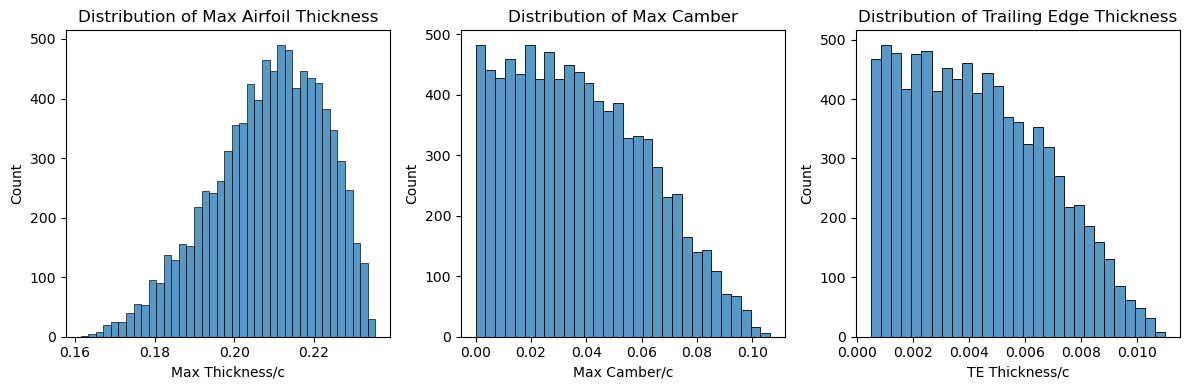

In [10]:
# Visualize distribution of maximum thickness/maximum camber/trailing edge thickness across airfoils
plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.histplot(data=np.max(thickness_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Airfoil Thickness')
ax.set(xlabel='Max Thickness/c')

plt.subplot(132)
ax = sns.histplot(data=np.max(camber_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Camber')
ax.set(xlabel='Max Camber/c')

plt.subplot(133)
ax = sns.histplot(data=thickness_arr_2d[:,499], stat='count')
ax.set_title('Distribution of Trailing Edge Thickness')
ax.set(xlabel='TE Thickness/c')

plt.tight_layout()
plt.show()

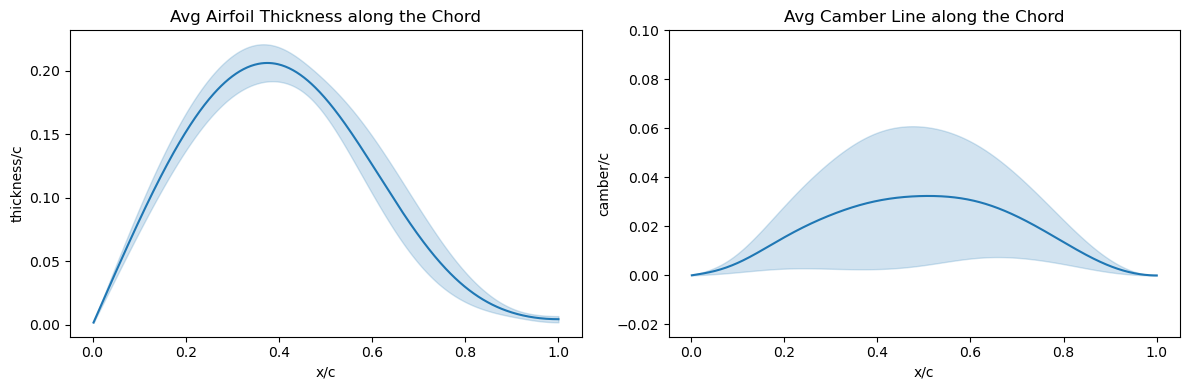

In [11]:
# Visualize average thickness along the chord and standard deviation across all airfoils
plt.figure(figsize=(12, 4))

plt.subplot(121)
ax = sns.lineplot(data=thickness_arr_1d, x=thickness_arr_1d[:,0], y=thickness_arr_1d[:,1], 
                  errorbar='sd', n_boot=(len(thickness_arr_1d)))
ax.set(xlabel='x/c', ylabel='thickness/c')
ax.set_title('Avg Airfoil Thickness along the Chord')

plt.subplot(122)
ax = sns.lineplot(data=camber_arr_1d, x=camber_arr_1d[:,0], y=camber_arr_1d[:,1], 
                  errorbar='sd', n_boot=(len(camber_arr_1d)))
ax.set(xlabel='x/c', ylabel='camber/c')
ax.set_title('Avg Camber Line along the Chord')
ax.set_ylim(ymin=-0.025, ymax=0.10)

plt.tight_layout()
plt.show()

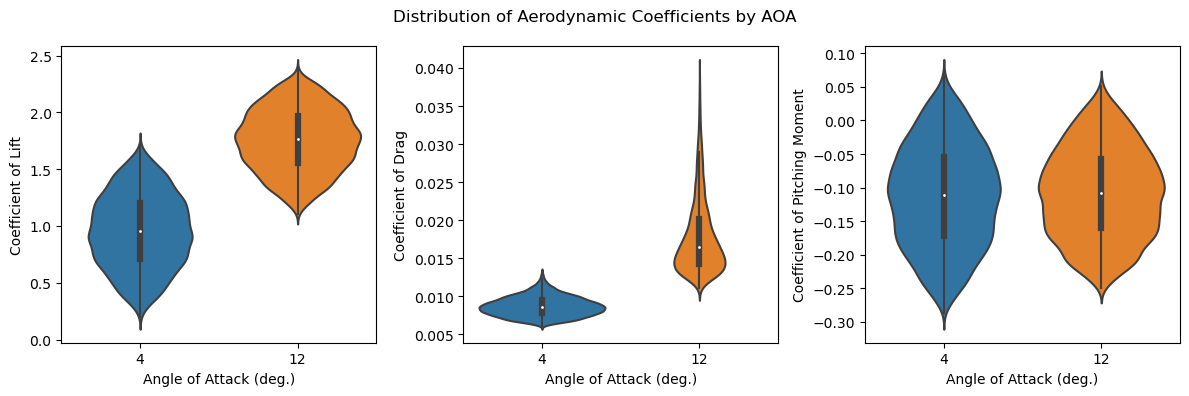

In [12]:
# Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
with h5py.File(data_path, 'r') as hf:
        cl_alpha04 = hf['alpha+04']['C_l'][()]
        cd_alpha04 = hf['alpha+04']['C_d'][()]
        cm_alpha04 = hf['alpha+04']['C_m'][()]
        
        cl_alpha12 = hf['alpha+12']['C_l'][()]
        cd_alpha12 = hf['alpha+12']['C_d'][()]
        cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.violinplot(data=[cl_alpha04, cl_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = sns.violinplot(data=[cd_alpha04, cd_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = sns.violinplot(data=[cm_alpha04, cm_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Distribution of Aerodynamic Coefficients by AOA')
plt.tight_layout()
plt.show()

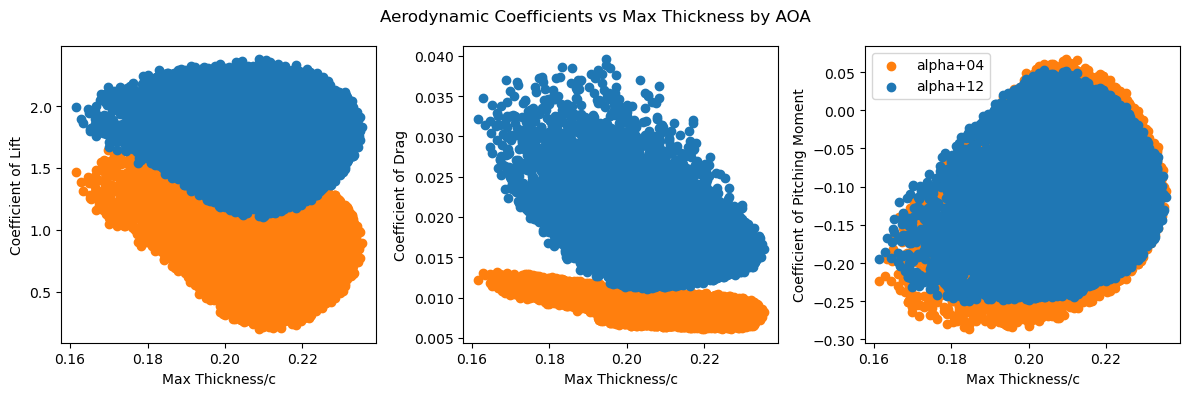

In [13]:
# Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
with h5py.File(data_path, 'r') as hf:
        cl_alpha04 = hf['alpha+04']['C_l'][()]
        cd_alpha04 = hf['alpha+04']['C_d'][()]
        cm_alpha04 = hf['alpha+04']['C_m'][()]
        
        cl_alpha12 = hf['alpha+12']['C_l'][()]
        cd_alpha12 = hf['alpha+12']['C_d'][()]
        cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.legend(loc='upper left')
plt.suptitle('Aerodynamic Coefficients vs Max Thickness by AOA')
plt.tight_layout()
plt.show()

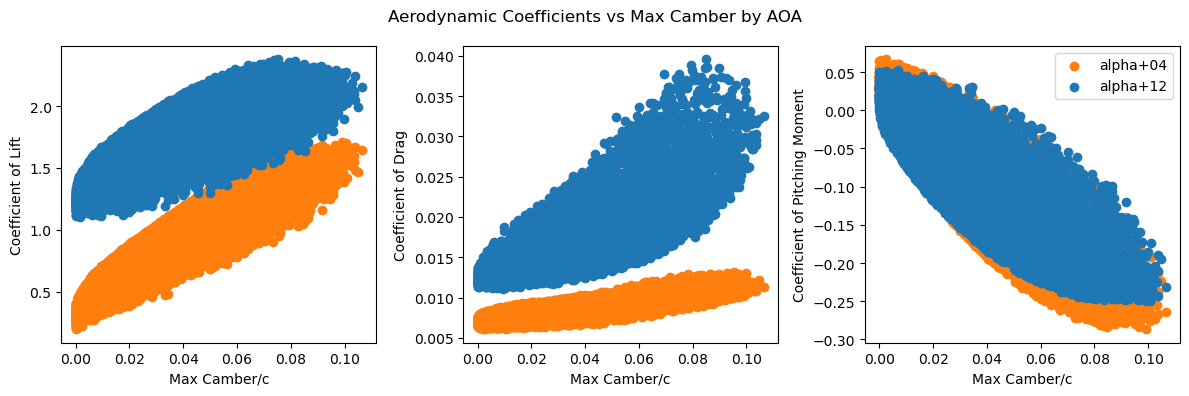

In [14]:
# Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
with h5py.File(data_path, 'r') as hf:
        cl_alpha04 = hf['alpha+04']['C_l'][()]
        cd_alpha04 = hf['alpha+04']['C_d'][()]
        cm_alpha04 = hf['alpha+04']['C_m'][()]
        
        cl_alpha12 = hf['alpha+12']['C_l'][()]
        cd_alpha12 = hf['alpha+12']['C_d'][()]
        cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Aerodynamic Coefficients vs Max Camber by AOA')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Dimension Reduction of Parameterizations

--------------------------------------------------
Number of Components = 1
Explained Variance:
[7.2918174]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[7.2918174  6.36463173]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[7.2918174  6.36463173 3.42187149]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761 0.05012966]


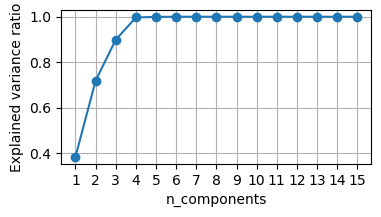

In [15]:
## Explore the PCA space of the cst data
# Aim to reduce cst data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
cst_std = std_scaler.fit_transform(cst)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(cst_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

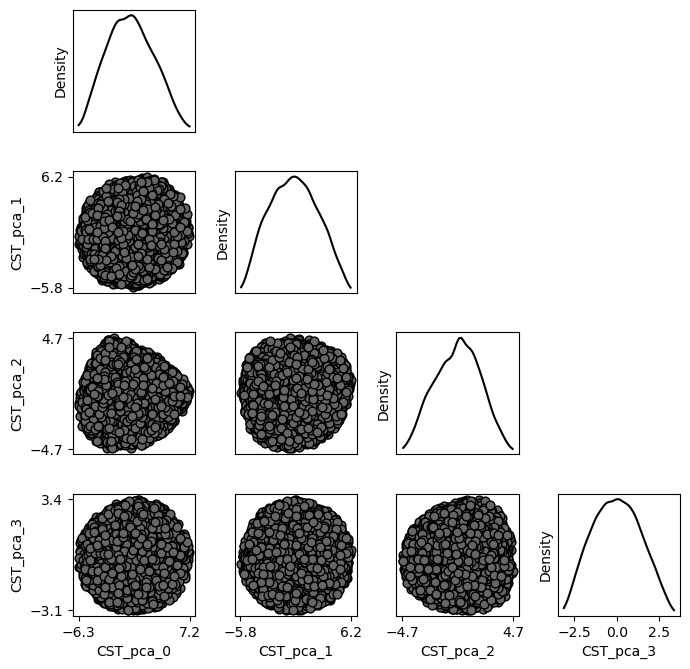

In [16]:
# Transform standardized cst data to (8996, 4) via PCA
pca = PCA(n_components=4)
cst_pca = pca.fit_transform(cst_std)

## Visualize distributions of CST parameters
# Capture number of parameters in CST representation
m = cst_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
cst_limits = []
for i in range(m):
    # Capture min and max values in each CST parameter across all airfoils
    lower = cst_pca[:,i].min()
    upper = cst_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    cst_limits.append([lower,upper])

# Create labels for CST parameters
cst_labels = ['CST_pca_{}'.format(i) for i in range(int((m)))]


# Plot marginal distributions of the CST data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst_pca[:,i].min(), cst_pca[:,i].max())
            kde = gaussian_kde(cst_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(cst_pca[:,j], cst_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]), 
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]), 
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


--------------------------------------------------
Number of Components = 1
Explained Variance:
[6.65828063]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[6.65828063 4.71747706]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[6.65828063 4.71747706 2.54334009]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004 0.02648279]


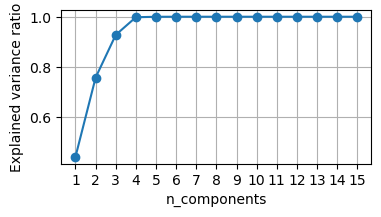

In [17]:
## Explore the PCA space of the bezier data
# Aim to reduce bezier data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
bezier_std = std_scaler.fit_transform(bezier)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(bezier_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

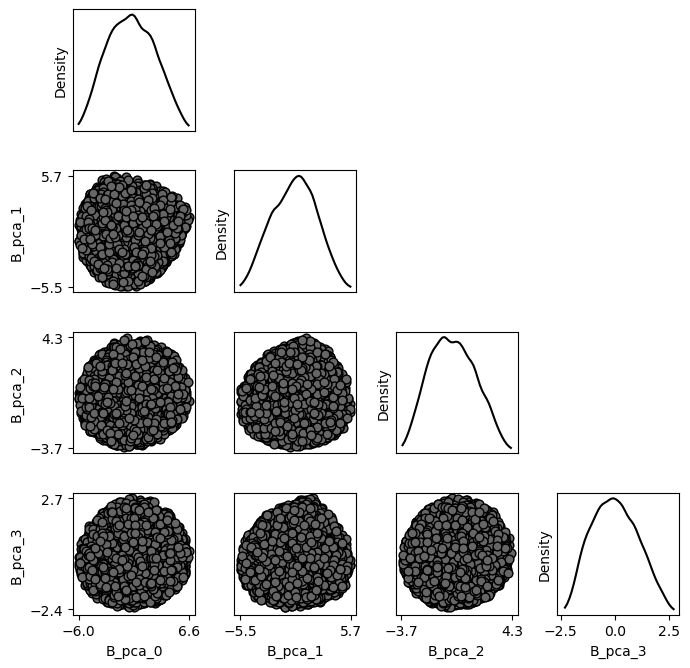

In [18]:
# Transform standardized bezier data to (8996, 4) via PCA
pca = PCA(n_components=4)
bezier_pca = pca.fit_transform(bezier_std)


## Visualize distributions of PCA Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier_pca[:,i].min()
    upper = bezier_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_pca_{}'.format(i) for i in range(int((m)))]

# Plot marginal distributions of the bezier data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier_pca[:,i].min(), bezier_pca[:,i].max())
            kde = gaussian_kde(bezier_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier_pca[:,j], bezier_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Examine Flow Field Data

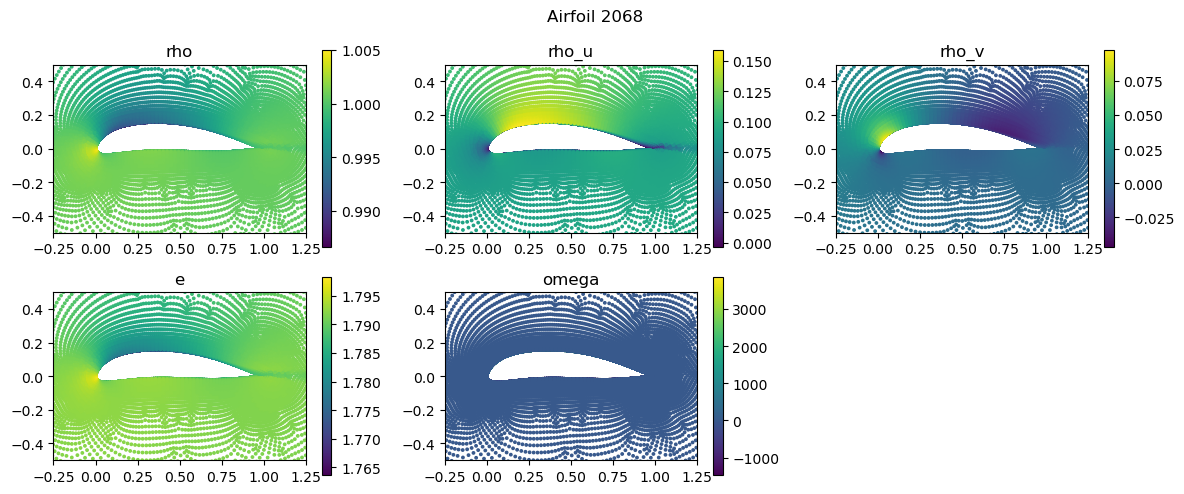

In [19]:
# Plot flow field data for randomly selected airfoils

val_list = ['rho', 'rho_u', 'rho_v', 'e', 'omega']

with h5py.File(data_path, 'r') as hf:
    idx = np.random.randint(hf['shape']['landmarks'].shape[0])
    
    x = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['x'][()]
    y = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['y'][()]
        
    plt.figure(figsize=(12, 5))
    for i, v in enumerate(val_list):
        val = hf['alpha+04']['flow_field']['{:04d}'.format(idx)][v][()]
        
        tf = (x >= -0.25) & (x <= 1.25) & (y >= -0.5) & (y <= 0.5)
        vmin, vmax = np.min(val[tf]), np.max(val[tf])
    
        plt.subplot(2, 3, i+1)
        plt.scatter(x, y, c=val, vmin=vmin, vmax=vmax, s=3)
        plt.xlim(-0.25, 1.25)
        plt.ylim(-0.5, 0.5)
        plt.colorbar()
        plt.title(v)
        plt.gca().set_aspect(1.)

    plt.suptitle('Airfoil {:04d}'.format(idx))
    plt.tight_layout()
    plt.show()